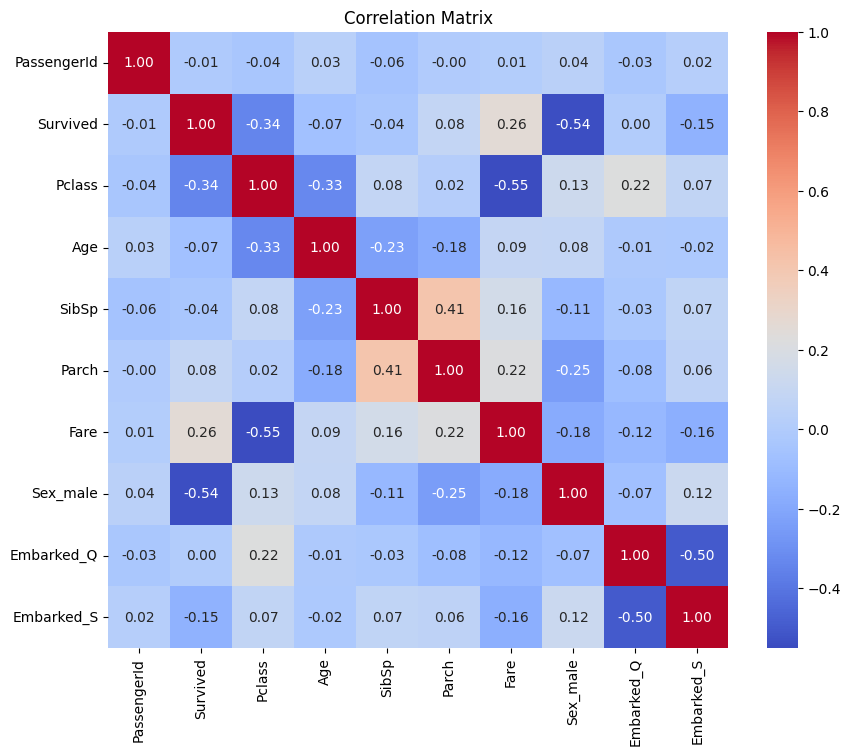

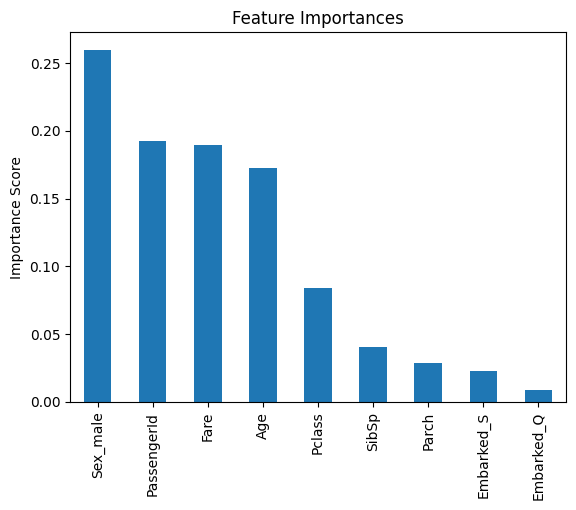

Pclass        True
SibSp         True
Parch         True
Sex_male      True
Embarked_S    True
dtype: bool

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv('../day01-python-warmups/train.csv')  # or your current working dataset
df.head()


df = df.drop(['Ticket', 'Cabin', 'Name'], axis=1)
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)


plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


X = df_encoded.drop('Survived', axis=1)
y = df_encoded['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

importances = model.feature_importances_
feat_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# Plot
feat_importance.plot(kind='bar', title='Feature Importances')
plt.ylabel('Importance Score')
plt.show()

lr = LogisticRegression(max_iter=1000)
rfe = RFE(lr, n_features_to_select=5)
rfe.fit(X, y)

selected = pd.Series(rfe.support_, index=X.columns)
selected[selected == True]
